In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init
import scipy.linalg as sci
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Parameter 초기화

In [3]:
## Learning parameters
initial_run = 1 #1: starts training from scratch; 0: resumes training 
n_epochs = 5000 #Number of training epochs, for observing the current performance set it to 0
learning_rate = 0.0005 #Learning rate

batch_size = 1024 #Mini-batch size
test_size = 10000 #Size of the validation/test set
batch_per_epoch = 20 #Numbers of mini-batches per epoch

anneal_param = 1.0 #Initial annealing parmeter
annealing_rate = 1.001 #Annealing rate

In [4]:
## System parameters
M = 64 #Number of BS antennas
P = 1 #Power
K =  2 #Number of users
L = 8 #Number of pilots
Lp = 2 #Number of paths
B = 30 #Number of feedback bits per user

## Limited scattering channel parameters
LSF_UE = np.array([0.0,0.0],dtype=np.float32) #Mean of path gains for K users
Mainlobe_UE= np.array([0,0],dtype=np.float32) #Center of the AoD range for K users
HalfBW_UE = np.array([30.0,30.0],dtype=np.float32) #Half of the AoD range for K users

# SNR
snr_dl = 10 #SNR in dB
noise_std_dl = np.float32(np.sqrt(1/2)*np.sqrt(P/10**(snr_dl/10))) #STD of the Gaussian noise (per real dim.)

### Full-CSI at the receiver (user) -> Limited feedback (AoD, channel gain quantizer)

#### Lloyd-max quantizer (optimal quantizer) for Gaussian distribution

In [9]:
with open("Lloyd-Max quantizer boundaries", 'rb') as fr:
    boundary_per_level = pickle.load(fr)
with open("Lloyd-Max quantizer levels", 'rb') as fr:
    centroid_per_level = pickle.load(fr)
with open("Uniform quantizer boundaries", 'rb') as fr:
    U_quantizer_boundary = pickle.load(fr)
with open("Uniform quantizer levels", 'rb') as fr:
    U_quantizer_level = pickle.load(fr)
    


In [5]:
## 리스트 인덱싱은 [층, 행, 열], [행, 열]임!
def generate_batch_data(batch_size,M,K,
                        Lp,#number of paths
                        LSF_UE #Mean of path gains for K users
                        ,Mainlobe_UE #Center of the AoD range for K users
                        ,HalfBW_UE #Half of the AoD range for K users
                        ):
    alphaR_input = np.zeros((batch_size,Lp,K))
    alphaI_input = np.zeros((batch_size,Lp,K))
    theta_input = np.zeros((batch_size,Lp,K))
    for kk in range(K): # for the number of users
        alphaR_input[:,:,kk] = np.random.normal(loc=LSF_UE[kk], scale=1.0/np.sqrt(2), size=[batch_size,Lp])
        alphaI_input[:,:,kk] = np.random.normal(loc=LSF_UE[kk], scale=1.0/np.sqrt(2), size=[batch_size,Lp])
        theta_input[:,:,kk] = np.random.uniform(low=Mainlobe_UE[kk]-HalfBW_UE[kk], high=Mainlobe_UE[kk]+HalfBW_UE[kk], size=[batch_size,Lp])
 
    #### Actual Channel
    from0toM = np.float32(np.arange(0, M, 1))
    alpha_act = alphaR_input + 1j*alphaI_input
    theta_act = (np.pi/180)*theta_input
    
    h_act = np.complex128(np.zeros((batch_size,M,K)))
    hR_act = np.float32(np.zeros((batch_size,M,K)))
    hI_act = np.float32(np.zeros((batch_size,M,K)))
    
    for kk in range(K):
        for ll in range(Lp):
            theta_act_expanded_temp = np.tile(np.reshape(theta_act[:,ll,kk],[-1,1]),(1,M))
            response_temp = np.exp(1j*np.pi*np.multiply(np.sin(theta_act_expanded_temp),from0toM))
            alpha_temp = np.reshape(alpha_act[:,ll,kk],[-1,1])
            h_act[:,:,kk] += (1/np.sqrt(Lp))*alpha_temp*response_temp
        hR_act[:,:,kk] = np.real(h_act[:,:,kk])
        hI_act[:,:,kk] = np.imag(h_act[:,:,kk])
        
    h_act = torch.tensor(h_act, dtype = torch.complex64).to(device)
    hR_act = torch.tensor(hR_act).to(device)
    hI_act = torch.tensor(hI_act).to(device)
    alphaR_input = torch.tensor(alphaR_input).to(device)
    alphaI_input = torch.tensor(alphaI_input).to(device)
    theta_input = torch.tensor(theta_input).to(device)
        
    return(h_act, alphaR_input, alphaI_input, theta_input)
### 여기서는 channel gain과 theta를 뱉도록 함

In [6]:
def rate_calc(V, H_act, num_users, noise_std):
    hH_V = torch.bmm((H_act.mH), V)
    hH_V = torch.pow(abs(hH_V), 2)
    noise_std = torch.tensor(noise_std).to(device)
    
    rate = torch.zeros(H_act.shape[0]).to(device)
    for kk in range(num_users):
        sig_pow = torch.sum(hH_V[:, kk, :], dim=-1)
        wanted_sig = hH_V[:, kk, kk]
        rate += torch.log2(1 + ( wanted_sig / (sig_pow - wanted_sig + 2 * noise_std ** 2)) ).to(device)
        
    sumrate = torch.mean(rate)
    
    return sumrate

In [13]:
iter = 10**4
quantization_levels = [2**1, 2**2, 2**3, 2**4, 2**5, 2**6, 2**7, 2**8, 2**9, 2**10]
h_act, alphaR, alphaI, theta = generate_batch_data(iter, M, K, Lp, LSF_UE, Mainlobe_UE, HalfBW_UE)
rate_MRT, rate_ZF = {}, {}

for q_levels in quantization_levels:
    L_Quant_level = centroid_per_level[q_levels] ## q_level 과 같음
    L_Quant_bound = boundary_per_level[q_levels] ## q_level-1
    U_Quant_level =  U_quantizer_level[q_levels] ## q_level과 같음
    U_Quant_bound = U_quantizer_boundary[q_levels] ## q_level+1
    
    Q_alphaR = torch.zeros_like(alphaR, dtype=torch.float32).to(device)
    Q_alphaI = torch.zeros_like(alphaI, dtype=torch.float32).to(device)
    Q_theta = torch.zeros_like(theta, dtype=torch.float32).to(device)
    
    ### Quantization loop
    for qq in range(q_levels):
        ### condition for alpha_R
        if qq == 0:
            mask = (alphaR <= L_Quant_bound[0])
        elif qq == q_levels-1:
            mask = (alphaR >= L_Quant_bound[qq-1])
        else:
            mask = (alphaR <= L_Quant_bound[qq]) & (alphaR >= L_Quant_bound[qq-1])
        Q_alphaR[mask] = L_Quant_level[qq]
        ### condition for alpha_I
        if qq == 0:
            mask = (alphaI <= L_Quant_bound[0])
        elif qq == q_levels-1:
            mask = (alphaI >= L_Quant_bound[qq-1])
        else:
            mask = (alphaI <= L_Quant_bound[qq]) & (alphaI >= L_Quant_bound[qq-1])
        Q_alphaI[mask] = L_Quant_level[qq]
        ### condition for theta
        mask = (theta <= U_Quant_bound[qq+1]) & (theta >= U_Quant_bound[qq])
        Q_theta[mask] = U_Quant_level[qq]
        
    ### reconstruct channel from quantized data
    Q_h = torch.zeros_like(h_act, dtype=torch.complex64).to(device)
    from0toM = torch.arange(0, M, 1, dtype=torch.float32).to(device)
    Q_alpha = torch.complex(Q_alphaR, Q_alphaI).to(device)
    Q_theta = (torch.pi/180) * Q_theta
    
    for kk in range(K):
        for ll in range(Lp):
            Q_theta_expended_temp = Q_theta[:, ll, kk].unsqueeze(1).repeat(1,M)
            Q_response_temp = torch.exp(1j * torch.pi * (torch.sin(Q_theta_expended_temp) * from0toM))
            Q_alpha_temp = Q_alpha[:, ll, kk].unsqueeze(1)
            Q_h[:, :, kk] += (1/ torch.sqrt(torch.tensor(Lp))) * (Q_response_temp * Q_alpha_temp)
            
    V_MRT = Q_h
    V_MRT = V_MRT / torch.sqrt(torch.einsum('bii->b', torch.bmm(V_MRT.mH , V_MRT))).unsqueeze(1).unsqueeze(2)
    rate_MRT[q_levels] = rate_calc(V_MRT, h_act, K, noise_std_dl)
    
    V_ZF = torch.linalg.pinv(Q_h.mH) # (batch, M, K)
    V_ZF = V_ZF / torch.sqrt(torch.einsum('bii->b', torch.bmm(V_ZF.mH , V_ZF))).unsqueeze(1).unsqueeze(2)
    rate_ZF[q_levels] = rate_calc(V_ZF, h_act, K, noise_std_dl)

In [14]:
print(rate_ZF)
print(rate_MRT)

{2: tensor(1.8198, device='cuda:0'), 4: tensor(3.2431, device='cuda:0'), 8: tensor(5.6509, device='cuda:0'), 16: tensor(8.5272, device='cuda:0'), 32: tensor(11.8652, device='cuda:0'), 64: tensor(13.8499, device='cuda:0'), 128: tensor(14.7128, device='cuda:0'), 256: tensor(15.0930, device='cuda:0'), 512: tensor(15.2471, device='cuda:0'), 1024: tensor(15.2974, device='cuda:0')}
{2: tensor(1.7171, device='cuda:0'), 4: tensor(3.4945, device='cuda:0'), 8: tensor(5.8555, device='cuda:0'), 16: tensor(8.5855, device='cuda:0'), 32: tensor(11.6781, device='cuda:0'), 64: tensor(12.7959, device='cuda:0'), 128: tensor(13.0727, device='cuda:0'), 256: tensor(13.1471, device='cuda:0'), 512: tensor(13.1662, device='cuda:0'), 1024: tensor(13.1714, device='cuda:0')}


In [25]:
with open('ZF with Full CSIR', 'wb') as fw:
    pickle.dump(rate_ZF, fw)
with open('MRT with Full CSIR', 'wb') as fw:
    pickle.dump(rate_MRT, fw)

In [7]:
with open("Lloyd-Max quantizer boundaries", 'rb') as fr:
    L_Quant_bound = pickle.load(fr)
with open("Lloyd-Max quantizer levels", 'rb') as fr:
    L_Quant_level = pickle.load(fr)
with open("Uniform quantizer boundaries", 'rb') as fr:
    U_Quant_bound = pickle.load(fr)
with open("Uniform quantizer levels", 'rb') as fr:
    U_Quant_level = pickle.load(fr)
    


In [8]:
def quantizer(R, I, T, Q_levels, L_bound, L_level, U_bound, U_level):
    Q_R = torch.zeros_like(R, dtype=torch.float32).to(device)
    Q_I = torch.zeros_like(I, dtype=torch.float32).to(device)
    Q_T = torch.zeros_like(T, dtype=torch.float32).to(device)
    
    for qq in range(Q_levels):
        ### condition for alpha_R
        if qq == 0:
            mask = (R <= L_bound[0])
        elif qq == Q_levels-1:
            mask = (R >= L_bound[qq-1])
        else:
            mask = (R <= L_bound[qq]) & (R >= L_bound[qq-1])
        Q_R[mask] = L_level[qq]
        
        ### condition for alpha_I
        if qq == 0:
            mask = (I <= L_bound[0])
        elif qq == Q_levels-1:
            mask = (I >= L_bound[qq-1])
        else:
            mask = (I <= L_bound[qq]) & (I >= L_bound[qq-1])
        Q_I[mask] = L_level[qq]
        
        ### condition for theta
        mask = (T <= U_bound[qq+1]) & (T >= U_bound[qq])
        Q_T[mask] = U_level[qq]
        
    return Q_R, Q_I, Q_T

In [9]:
def reconstruct_and_evaluate(Q_alphaR, Q_alphaI, Q_theta, h_act, num_paths):
    ### reconstruct channel from quantized data
    Q_h = torch.zeros_like(h_act, dtype=torch.complex64).to(device)
    from0toM = torch.arange(0, M, 1, dtype=torch.float32).to(device)
    Q_alpha = torch.complex(Q_alphaR, Q_alphaI).to(device)
    Q_theta = (torch.pi/180) * Q_theta
    
    for kk in range(K):
        for ll in range(num_paths):
            Q_theta_expended_temp = Q_theta[:, ll, kk].unsqueeze(1).repeat(1,M)
            Q_response_temp = torch.exp(1j * torch.pi * (torch.sin(Q_theta_expended_temp) * from0toM))
            Q_alpha_temp = Q_alpha[:, ll, kk].unsqueeze(1)
            Q_h[:, :, kk] += (1/ torch.sqrt(torch.tensor(num_paths))) * (Q_response_temp * Q_alpha_temp)
            
    V_MRT = Q_h
    V_MRT = V_MRT / torch.sqrt(torch.einsum('bii->b', torch.bmm(V_MRT.mH , V_MRT))).unsqueeze(1).unsqueeze(2)
    rate_MRT = rate_calc(V_MRT, h_act, K, noise_std_dl)
    
    V_ZF = torch.linalg.pinv(Q_h.mH) # (batch, M, K)
    V_ZF = V_ZF / torch.sqrt(torch.einsum('bii->b', torch.bmm(V_ZF.mH , V_ZF))).unsqueeze(1).unsqueeze(2)
    rate_ZF = rate_calc(V_ZF, h_act, K, noise_std_dl)
    
    return rate_MRT, rate_ZF

In [10]:
def rate_calc(V, H_act, num_users, noise_std):
    hH_V = torch.bmm((H_act.mH), V)
    hH_V = torch.pow(abs(hH_V), 2)
    noise_std = torch.tensor(noise_std).to(device)
    
    rate = torch.zeros(H_act.shape[0]).to(device)
    for kk in range(num_users):
        sig_pow = torch.sum(hH_V[:, kk, :], dim=-1)
        wanted_sig = hH_V[:, kk, kk]
        rate += torch.log2(1 + ( wanted_sig / (sig_pow - wanted_sig + 2 * noise_std ** 2)) ).to(device)
        
    sumrate = torch.mean(rate)
    
    return sumrate

In [31]:
Lp = [2, 4, 6, 8]
iter = 10 ** 4
for ll in range(len(Lp)):
    paths = Lp[ll]
    if paths == 4:
        rate_Lp4_MRT = list()
        rate_Lp4_ZF = list()
        h_act, alphaR, alphaI, theta = generate_batch_data(iter, M, K, paths, LSF_UE, Mainlobe_UE, HalfBW_UE)
        bits = [1, 2, 3, 4, 5]
        for bb in bits:
           Q_alphaR, Q_alphaI, Q_theta = quantizer(alphaR, alphaI, theta, 2 ** bb, L_Quant_bound[2 ** bb], L_Quant_level[2 ** bb], U_Quant_bound[2 ** bb], U_Quant_level[2 ** bb])
           rate_MRT, rate_ZF = reconstruct_and_evaluate(Q_alphaR, Q_alphaI, Q_theta, h_act, paths)
           rate_Lp4_MRT.append(rate_MRT.item())
           rate_Lp4_ZF.append(rate_ZF.item())
    elif paths == 2:
        rate_Lp2_MRT = list()
        rate_Lp2_ZF = list()
        h_act, alphaR, alphaI, theta = generate_batch_data(iter, M, K, paths, LSF_UE, Mainlobe_UE, HalfBW_UE)    
        bits = [1,2,3,4,5,6,7,8,9,10]
        for bb in bits:
            Q_alphaR, Q_alphaI, Q_theta = quantizer(alphaR, alphaI, theta, 2 ** bb, L_Quant_bound[2 ** bb], L_Quant_level[2 ** bb], U_Quant_bound[2 ** bb], U_Quant_level[2 ** bb])
            rate_MRT, rate_ZF = reconstruct_and_evaluate(Q_alphaR, Q_alphaI, Q_theta, h_act, paths)
            rate_Lp2_MRT.append(rate_MRT.item())
            rate_Lp2_ZF.append(rate_ZF.item())
           
    elif paths == 6:
        rate_Lp6_MRT = list()
        rate_Lp6_ZF = list()
        h_act, alphaR, alphaI, theta = generate_batch_data(iter, M, K, paths, LSF_UE, Mainlobe_UE, HalfBW_UE)
        bits = [1, 2, 3, 4, 5, 6]
        for bb in bits:
            if (bb == 1) or (bb == 3) or (bb == 5): ### parameter당 6, 12, 18, 24, 30, 36, 42, 48
                if bb == 1:
                    bit = 1
                elif bb == 3:
                    bit = 2
                else:
                    bit =3
                Q_alphaR, Q_alphaI, Q_theta = quantizer(alphaR, alphaI, theta, 2 ** bit, L_Quant_bound[2 ** bit], L_Quant_level[2 ** bit], U_Quant_bound[2 ** bit], U_Quant_level[2 ** bit])
                rate_MRT, rate_ZF = reconstruct_and_evaluate(Q_alphaR, Q_alphaI, Q_theta, h_act, paths)
            elif bb == 2:
                alphaR_1 = alphaR[:, :4, :]
                alphaR_2 = alphaR[:, 4:, :]
                alphaI_1 = alphaI[:, :4, :]
                alphaI_2 = alphaI[:, 4:, :]
                theta_1 = theta[:, :4, :]
                theta_2 = theta[:, 4:, :]
                Q_bit_1 = 1
                Q_bit_2 = 2
                Q_alphaR_1, Q_alphaI_1, Q_theta_1 = quantizer(alphaR_1, alphaI_1, theta_1, 2**Q_bit_1, L_Quant_bound[2**Q_bit_1], L_Quant_level[2**Q_bit_1], U_Quant_bound[2**Q_bit_1], U_Quant_level[2**Q_bit_1])
                Q_alphaR_2, Q_alphaI_2, Q_theta_2 = quantizer(alphaR_2, alphaI_2, theta_2, 2**Q_bit_2, L_Quant_bound[2**Q_bit_2], L_Quant_level[2**Q_bit_2], U_Quant_bound[2**Q_bit_2], U_Quant_level[2**Q_bit_2])
                Q_alphaR = torch.cat((Q_alphaR_1, Q_alphaR_2), dim=1)
                Q_alphaI = torch.cat((Q_alphaI_1, Q_alphaI_2), dim=1)
                Q_theta = torch.cat((Q_theta_1, Q_theta_2), dim=1)
                rate_MRT, rate_ZF = reconstruct_and_evaluate(Q_alphaR, Q_alphaI, Q_theta, h_act, paths)
            elif bb == 4:
                alphaR_1 = alphaR[:, :4, :]
                alphaR_2 = alphaR[:, 4:, :]
                alphaI_1 = alphaI[:, :4, :]
                alphaI_2 = alphaI[:, 4:, :]
                theta_1 = theta[:, :4, :]
                theta_2 = theta[:, 4:, :]
                Q_bit_1 = 3
                Q_bit_2 = 2
                Q_alphaR_1, Q_alphaI_1, Q_theta_1 = quantizer(alphaR_1, alphaI_1, theta_1, 2**Q_bit_1, L_Quant_bound[2**Q_bit_1], L_Quant_level[2**Q_bit_1], U_Quant_bound[2**Q_bit_1], U_Quant_level[2**Q_bit_1])
                Q_alphaR_2, Q_alphaI_2, Q_theta_2 = quantizer(alphaR_2, alphaI_2, theta_2, 2**Q_bit_2, L_Quant_bound[2**Q_bit_2], L_Quant_level[2**Q_bit_2], U_Quant_bound[2**Q_bit_2], U_Quant_level[2**Q_bit_2])
                Q_alphaR = torch.cat((Q_alphaR_1, Q_alphaR_2), dim=1)
                Q_alphaI = torch.cat((Q_alphaI_1, Q_alphaI_2), dim=1)
                Q_theta = torch.cat((Q_theta_1, Q_theta_2), dim=1)
                rate_MRT, rate_ZF = reconstruct_and_evaluate(Q_alphaR, Q_alphaI, Q_theta, h_act, paths)
            else:
                alphaR_1 = alphaR[:, :4, :]
                alphaR_2 = alphaR[:, 4:, :]
                alphaI_1 = alphaI[:, :4, :]
                alphaI_2 = alphaI[:, 4:, :]
                theta_1 = theta[:, :4, :]
                theta_2 = theta[:, 4:, :]
                Q_bit_1 = 3
                Q_bit_2 = 4
                Q_alphaR_1, Q_alphaI_1, Q_theta_1 = quantizer(alphaR_1, alphaI_1, theta_1, 2**Q_bit_1, L_Quant_bound[2**Q_bit_1], L_Quant_level[2**Q_bit_1], U_Quant_bound[2**Q_bit_1], U_Quant_level[2**Q_bit_1])
                Q_alphaR_2, Q_alphaI_2, Q_theta_2 = quantizer(alphaR_2, alphaI_2, theta_2, 2**Q_bit_2, L_Quant_bound[2**Q_bit_2], L_Quant_level[2**Q_bit_2], U_Quant_bound[2**Q_bit_2], U_Quant_level[2**Q_bit_2])
                Q_alphaR = torch.cat((Q_alphaR_1, Q_alphaR_2), dim=1)
                Q_alphaI = torch.cat((Q_alphaI_1, Q_alphaI_2), dim=1)
                Q_theta = torch.cat((Q_theta_1, Q_theta_2), dim=1)
                rate_MRT, rate_ZF = reconstruct_and_evaluate(Q_alphaR, Q_alphaI, Q_theta, h_act, paths)
            rate_Lp6_MRT.append(rate_MRT.item())
            rate_Lp6_ZF.append(rate_ZF.item())
    else:
        rate_Lp8_MRT = list()
        rate_Lp8_ZF = list()
        h_act, alphaR, alphaI, theta = generate_batch_data(iter, M, K, paths, LSF_UE, Mainlobe_UE, HalfBW_UE)
        bits = [1, 2, 3, 4]
        for bb in bits:
            if (bb == 1) or (bb == 3): ## parameter 당 8bit, 16bit
                if bb == 1:
                    bit = 1
                else:
                    bit = 2
                Q_alphaR, Q_alphaI, Q_theta = quantizer(alphaR, alphaI, theta, 2 ** bit, L_Quant_bound[2 ** bit], L_Quant_level[2 ** bit], U_Quant_bound[2 ** bit], U_Quant_level[2 ** bit])
                rate_MRT, rate_ZF = reconstruct_and_evaluate(Q_alphaR, Q_alphaI, Q_theta, h_act, paths)
            elif bb == 2:
                alphaR_1 = alphaR[:, :4, :]
                alphaR_2 = alphaR[:, 4:, :]
                alphaI_1 = alphaI[:, :4, :]
                alphaI_2 = alphaI[:, 4:, :]
                theta_1 = theta[:, :4, :]
                theta_2 = theta[:, 4:, :]
                Q_bit_1 = 1
                Q_bit_2 = 2
                Q_alphaR_1, Q_alphaI_1, Q_theta_1 = quantizer(alphaR_1, alphaI_1, theta_1, 2**Q_bit_1, L_Quant_bound[2**Q_bit_1], L_Quant_level[2**Q_bit_1], U_Quant_bound[2**Q_bit_1], U_Quant_level[2**Q_bit_1])
                Q_alphaR_2, Q_alphaI_2, Q_theta_2 = quantizer(alphaR_2, alphaI_2, theta_2, 2**Q_bit_2, L_Quant_bound[2**Q_bit_2], L_Quant_level[2**Q_bit_2], U_Quant_bound[2**Q_bit_2], U_Quant_level[2**Q_bit_2])
                Q_alphaR = torch.cat((Q_alphaR_1, Q_alphaR_2), dim=1)
                Q_alphaI = torch.cat((Q_alphaI_1, Q_alphaI_2), dim=1)
                Q_theta = torch.cat((Q_theta_1, Q_theta_2), dim=1)
                rate_MRT, rate_ZF = reconstruct_and_evaluate(Q_alphaR, Q_alphaI, Q_theta, h_act, paths)
            else:
                alphaR_1 = alphaR[:, :2, :]
                alphaR_2 = alphaR[:, 2:, :]
                alphaI_1 = alphaI[:, :2, :]
                alphaI_2 = alphaI[:, 2:, :]
                theta_1 = theta[:, :2, :]
                theta_2 = theta[:, 2:, :]
                Q_bit_1 = 4
                Q_bit_2 = 2
                Q_alphaR_1, Q_alphaI_1, Q_theta_1 = quantizer(alphaR_1, alphaI_1, theta_1, 2**Q_bit_1, L_Quant_bound[2**Q_bit_1], L_Quant_level[2**Q_bit_1], U_Quant_bound[2**Q_bit_1], U_Quant_level[2**Q_bit_1])
                Q_alphaR_2, Q_alphaI_2, Q_theta_2 = quantizer(alphaR_2, alphaI_2, theta_2, 2**Q_bit_2, L_Quant_bound[2**Q_bit_2], L_Quant_level[2**Q_bit_2], U_Quant_bound[2**Q_bit_2], U_Quant_level[2**Q_bit_2])
                Q_alphaR = torch.cat((Q_alphaR_1, Q_alphaR_2), dim=1)
                Q_alphaI = torch.cat((Q_alphaI_1, Q_alphaI_2), dim=1)
                Q_theta = torch.cat((Q_theta_1, Q_theta_2), dim=1)
                rate_MRT, rate_ZF = reconstruct_and_evaluate(Q_alphaR, Q_alphaI, Q_theta, h_act, paths)
            rate_Lp8_MRT.append(rate_MRT.item())
            rate_Lp8_ZF.append(rate_ZF.item())

In [32]:
print(rate_Lp2_MRT)
print(rate_Lp4_MRT)
print(rate_Lp6_MRT)
print(rate_Lp8_MRT)
print(rate_Lp2_ZF)
print(rate_Lp4_ZF)
print(rate_Lp6_ZF)
print(rate_Lp8_ZF)

[1.7510770559310913, 3.5110952854156494, 5.869259834289551, 8.614035606384277, 11.667488098144531, 12.778050422668457, 13.067977905273438, 13.138080596923828, 13.155998229980469, 13.16069507598877]
[1.7111624479293823, 3.013597011566162, 4.821205139160156, 6.9340715408325195, 10.205337524414062]
[1.7831625938415527, 2.5046498775482178, 2.7713358402252197, 4.022841930389404, 4.189844608306885, 5.086004734039307]
[1.8255356550216675, 2.5763449668884277, 2.6565587520599365, 3.79235577583313]
[1.8357722759246826, 3.306422472000122, 5.645095348358154, 8.552382469177246, 11.834477424621582, 13.864141464233398, 14.719371795654297, 15.109402656555176, 15.263932228088379, 15.318343162536621]
[1.7020496129989624, 2.827151298522949, 4.701223850250244, 7.029539108276367, 10.82348918914795]
[1.7397509813308716, 2.3676342964172363, 2.6613869667053223, 3.925569534301758, 4.156041622161865, 5.004725456237793]
[1.7933818101882935, 2.4950473308563232, 2.6000285148620605, 3.615760564804077]


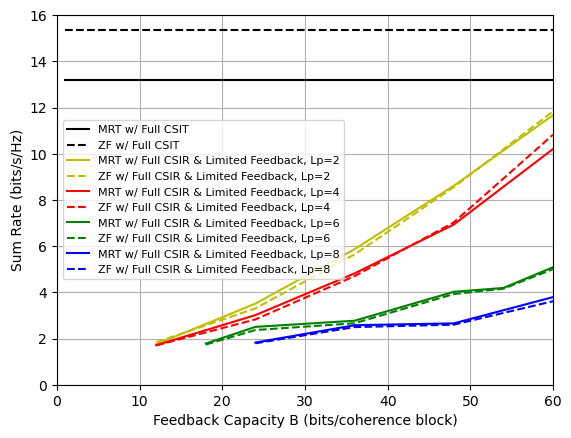

In [33]:
plt.plot([1, 3, 6, 15, 20, 30, 40, 50, 60], [13.1916 for _ in range(len([1, 3, 6, 15, 20, 30, 40, 50, 60]))], '-k', label = 'MRT w/ Full CSIT')
plt.plot([1, 3, 6, 15, 20, 30, 40, 50, 60], [15.3562 for _ in range(len([1, 3, 6, 15, 20, 30, 40, 50, 60]))], '--k', label = 'ZF w/ Full CSIT')

plt.plot([12*(i+1) for i in range(10)],rate_Lp2_MRT, '-y', label='MRT w/ Full CSIR & Limited Feedback, Lp=2')
plt.plot([12*(i+1) for i in range(10)],rate_Lp2_ZF, '--y', label='ZF w/ Full CSIR & Limited Feedback, Lp=2')

plt.plot([12, 24, 36, 48, 60],rate_Lp4_MRT, '-r', label='MRT w/ Full CSIR & Limited Feedback, Lp=4')
plt.plot([12, 24, 36, 48, 60],rate_Lp4_ZF, '--r', label='ZF w/ Full CSIR & Limited Feedback, Lp=4')

plt.plot([18, 24, 36, 48, 54, 60],rate_Lp6_MRT, '-g', label='MRT w/ Full CSIR & Limited Feedback, Lp=6')
plt.plot([18, 24, 36, 48, 54, 60],rate_Lp6_ZF, '--g', label='ZF w/ Full CSIR & Limited Feedback, Lp=6')

plt.plot([24, 36, 48, 60],rate_Lp8_MRT, '-b', label='MRT w/ Full CSIR & Limited Feedback, Lp=8')
plt.plot([24, 36, 48, 60],rate_Lp8_ZF, '--b', label='ZF w/ Full CSIR & Limited Feedback, Lp=8')

plt.xlabel('Feedback Capacity B (bits/coherence block)')
plt.xlim([0,60])
plt.ylabel('Sum Rate (bits/s/Hz)')
plt.ylim([0,16])
plt.legend(loc='best', fontsize='8')
plt.grid()
plt.show()